In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel(r"C:\Users\prati\Downloads\EastWestAirlines.xlsx")

In [3]:
df = df.drop(columns=["ID#"])

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB
None
            Balance    Qual_miles    cc1_miles    cc2_miles    cc3_miles  \
count  3.999000e+03   3999.000000  3999.000000  3999.000000  3999.000000   
mean   7.360133e+04    144.114529     2.059515     1.014504     1.012253   
std    1.007757e+05  

In [5]:
print(df.isnull().sum())

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

In [22]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [23]:
df_clean = df_clean.loc[:, df_clean.nunique() > 1]

In [24]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

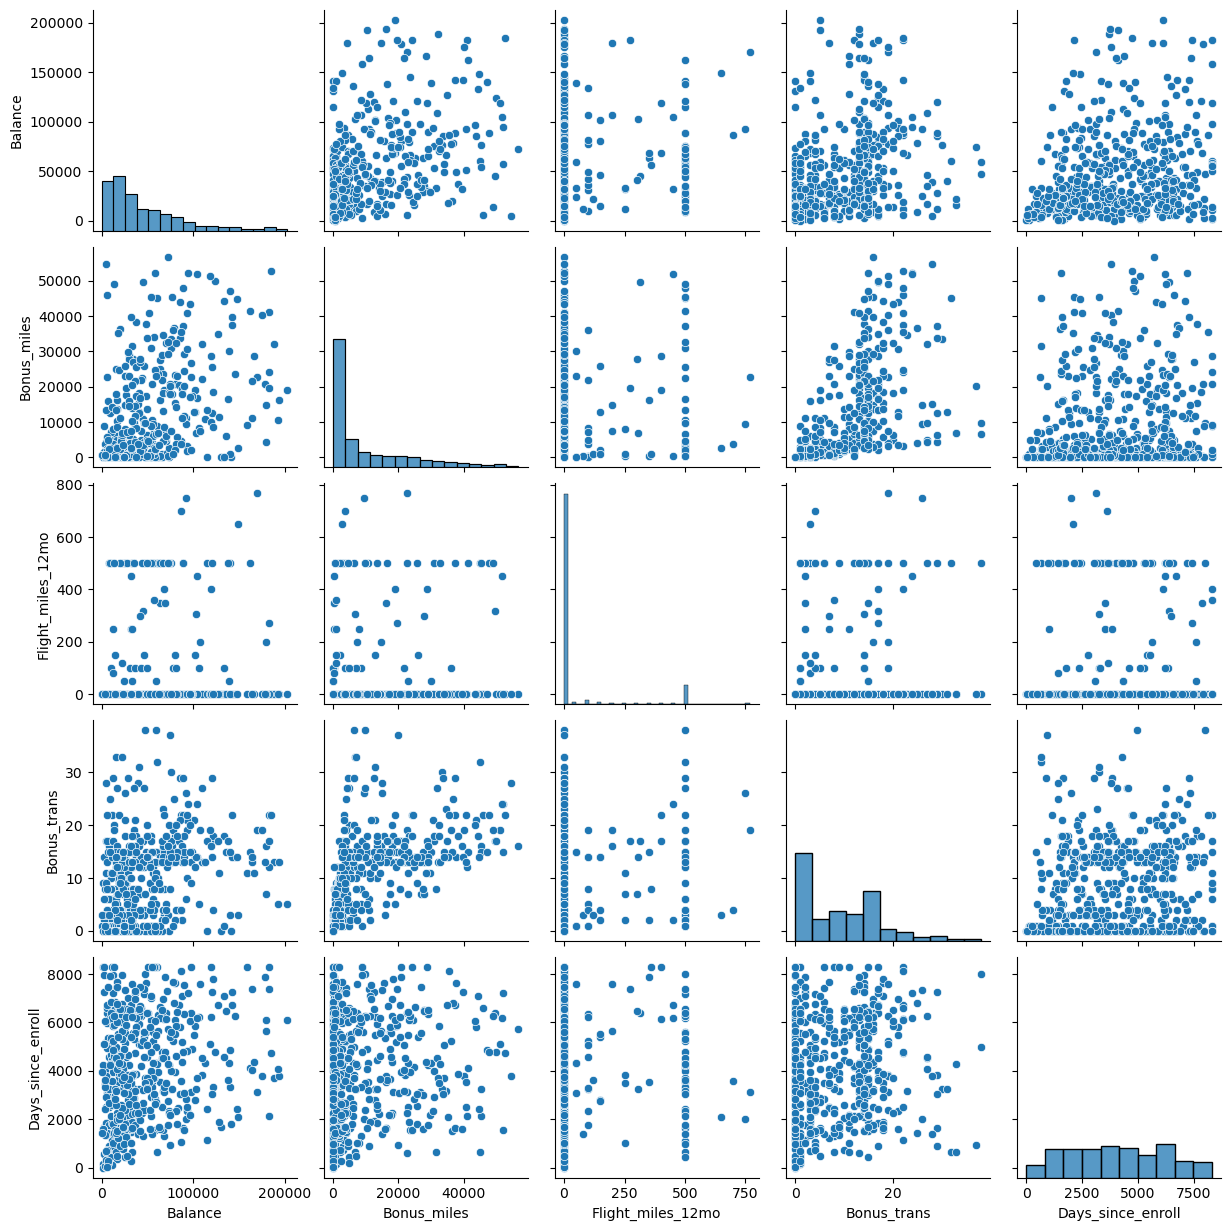

In [25]:
features = [
    "Balance",
    "Bonus_miles",
    "Flight_miles_12mo",
    "Bonus_trans",
    "Days_since_enroll"
]

sns.pairplot(df_clean[features].sample(500))
plt.savefig("clean_pairplot.png", dpi=300)
plt.show()

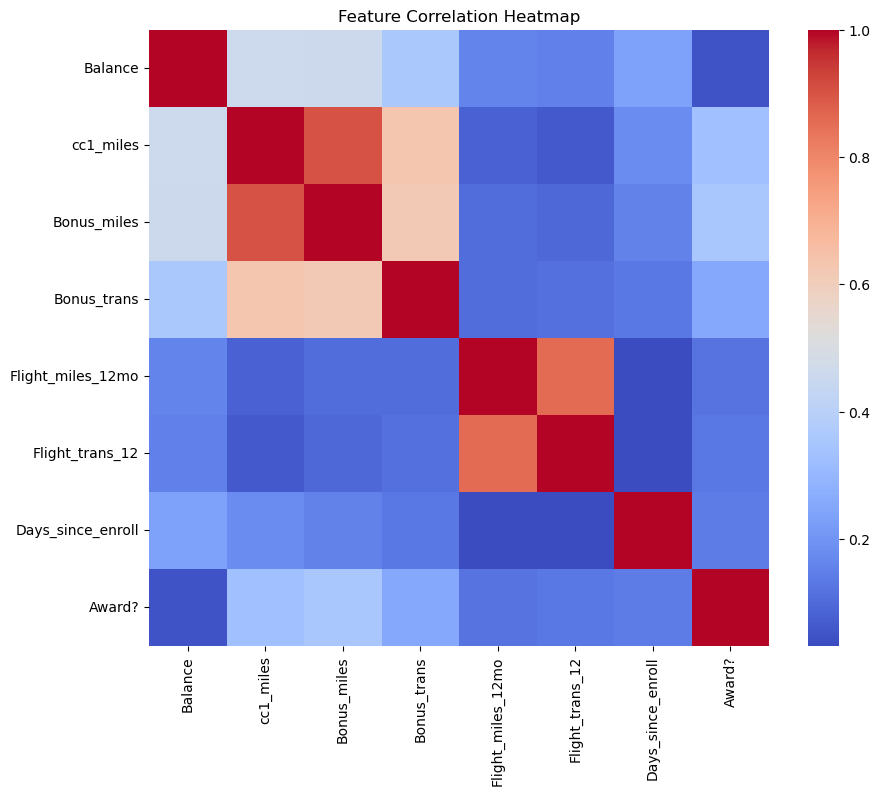

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

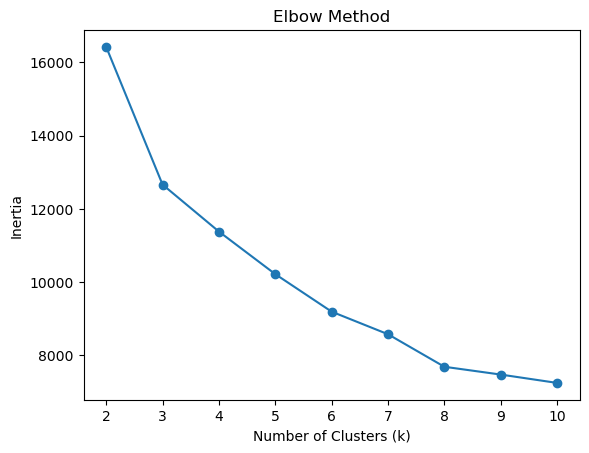

In [27]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

In [29]:
kmeans_sil = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_sil)

K-Means Silhouette Score: 0.22962827467448732


In [30]:
dbscan = DBSCAN(eps=1.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [31]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_sil = silhouette_score(scaled_data[mask], dbscan_labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_sil)
else:
    print("DBSCAN produced insufficient clusters")

DBSCAN Silhouette Score: 0.2628931398722154


In [32]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

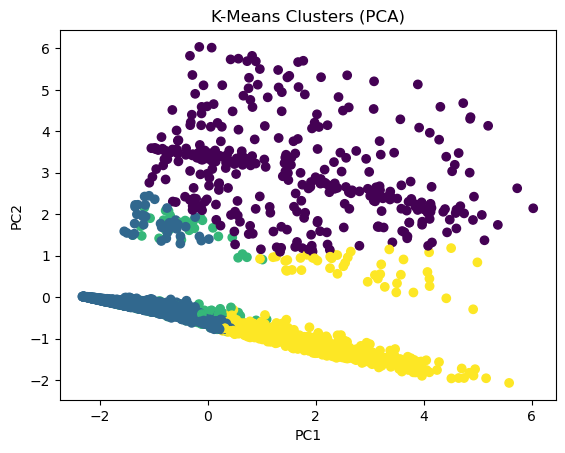

In [33]:
plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

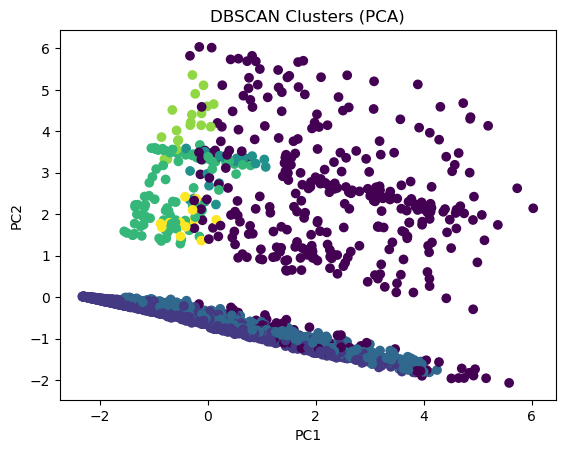

In [34]:
plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=dbscan_labels)
plt.title("DBSCAN Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [35]:
df_clean["KMeans_Cluster"] = kmeans_labels

In [36]:
cluster_summary = df_clean.groupby("KMeans_Cluster").mean()

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
                     Balance  cc1_miles   Bonus_miles  Bonus_trans  \
KMeans_Cluster                                                       
0               65113.991501   2.065156  14463.011331    11.756374   
1               25552.377339   1.092516   2772.070686     5.465696   
2               36146.795071   1.138781   3479.610895     6.156939   
3               75069.773131   3.299113  26368.466413    16.259823   

                Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
KMeans_Cluster                                                          
0                      428.084986         1.308782        4098.711048   
1                        4.810811         0.038462        2068.735967   
2                        4.203632         0.036316        5642.370947   
3                        6.510773         0.055767        4439.508238   

                  Award?  
KMeans_Cluster            
0               0.447592  
1               0.107069  
2             

In [37]:
print("""5. Clustering Methods
5.1 K-Means Clustering
The Elbow Method was used to determine the optimal number of clusters. Based on the elbow curve, four clusters were selected.
The K-Means clustering produced a silhouette score of:
0.2296
This indicates moderate cluster separation, which is expected in real behavioral datasets.
5.2 DBSCAN Clustering
DBSCAN was applied to detect density-based clusters and potential outliers.
The DBSCAN silhouette score was:
0.2629
This slightly higher score suggests that density-based clustering captures some structure not detected by K-Means.
6. Cluster Analysis and Interpretation
Four customer segments were identified using K-Means clustering.
Cluster 0: Frequent Travelers
Customers in this cluster show high flight activity and significant mileage balances. They frequently redeem awards and represent loyal, high-value travelers.
Business implication: These customers should be prioritized for retention programs and premium services.
Cluster 1: Low-Activity Customers
This group has low mileage balances and minimal flight engagement. Award redemption is rare.
Business implication: Marketing campaigns should target this segment to increase engagement.
Cluster 2: Dormant Long-Term Members
These customers have been enrolled for a long time but show very low recent flight activity.
Business implication: Reactivation strategies may help recover dormant customers.
Cluster 3: Premium Reward Maximizers
This cluster has the highest mileage balances and credit card activity, with frequent bonus transactions and award redemption.
Business implication: These customers are valuable for financial partnerships and loyalty optimization.
7. Visualization of Clusters
Principal Component Analysis (PCA) was used to project high-dimensional data into two dimensions for visualization. Scatter plots demonstrate moderate separation among clusters, confirming segmentation structure.
8. Evaluation of Clustering Performance
Silhouette scores were used to evaluate cluster quality:
K-Means: 0.2296
DBSCAN: 0.2629
These scores indicate acceptable cluster structure for real-world customer behavior data. DBSCAN performed slightly better, suggesting density-based relationships among customers.
9. Conclusion
This study successfully segmented East-West Airlines customers into four meaningful groups using clustering techniques. Each segment represents distinct behavioral patterns with clear business implications.
The results support strategic decision-making in marketing, loyalty programs, and customer retention. Although cluster separation is moderate, the segmentation provides valuable insights into customer behavior.
Future work may include hierarchical clustering, advanced feature engineering, and model tuning to further improve segmentation quality.""")

5. Clustering Methods
5.1 K-Means Clustering
The Elbow Method was used to determine the optimal number of clusters. Based on the elbow curve, four clusters were selected.
The K-Means clustering produced a silhouette score of:
0.2296
This indicates moderate cluster separation, which is expected in real behavioral datasets.
5.2 DBSCAN Clustering
DBSCAN was applied to detect density-based clusters and potential outliers.
The DBSCAN silhouette score was:
0.2629
This slightly higher score suggests that density-based clustering captures some structure not detected by K-Means.
6. Cluster Analysis and Interpretation
Four customer segments were identified using K-Means clustering.
Cluster 0: Frequent Travelers
Customers in this cluster show high flight activity and significant mileage balances. They frequently redeem awards and represent loyal, high-value travelers.
Business implication: These customers should be prioritized for retention programs and premium services.
Cluster 1: Low-Activity C